RNN SMS SPAM DETECTION

DISCOVERY PHASE - DATA PREPARATION
No CSV found. Creating mock SMS dataset...
Mock dataset created: 5000 rows
Dataset: 5000 rows, 2 columns

First 5 rows:
                                  message  label
0                   How was your weekend?      0
1                   Thanks for your help!      0
2  Your bank account has been compromised      1
3                   Claim your prize now!      1
4             Limited time offer! 80% off      1

Label distribution:
label
0    2500
1    2500
Name: count, dtype: int64
Ham: 2500 messages
Spam: 2500 messages

TOKENIZE TEXT
Number of unique words: 117
Padded sequences shape: (5000, 50)

SPLIT DATA (Train/Validation)
Training set: 4000 messages
Validation set: 1000 messages

TECHNICAL PHASE - BUILD RNN MODEL


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None

TRAIN WITH EARLY STOPPING
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.4970 - loss: 0.6936 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.5045 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9005 - loss: 0.2339 - val_accuracy: 0.9780 - val_loss: 0.0915
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.9762 - loss: 0.1009 - val_accuracy: 0.9780 - val_loss: 0.0919
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9762 - loss: 0.0995 - val_accuracy: 0.9780 - val_loss: 0.0913
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.9762 - loss: 0.0994 - val_accuracy: 0.9780 - val_loss: 0.0919
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.9762 - loss: 0.0991 - val_accuracy: 0.9780 - val_loss: 0.0918
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy:

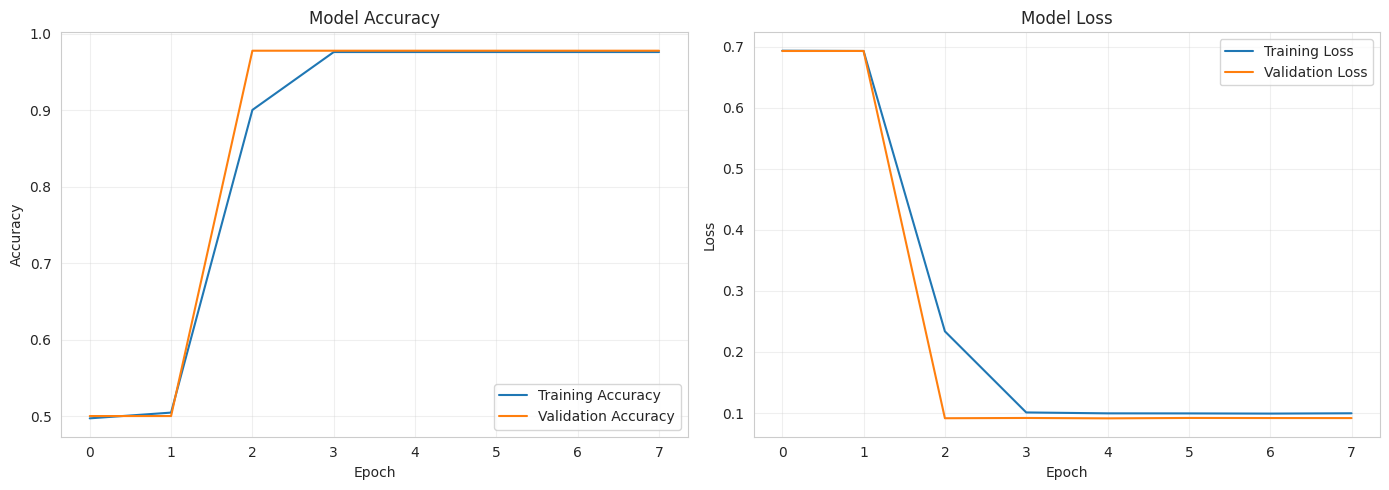


EVALUATE MODEL
Accuracy:  0.9780
Precision: 1.0000
Recall:    0.9560
F1-Score:  0.9775

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       500
           1       1.00      0.96      0.98       500

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000


Confusion Matrix:
[[500   0]
 [ 22 478]]

ACTION PHASE - TEST CUSTOM MESSAGES

Testing custom messages:
--------------------------------------------------
Message: Hey, are we still meeting for lunch?
Prediction: HAM (Score: 0.0394, Confidence: 96.1%)
----------------------------------------
Message: URGENT! Your account is locked. Click here to verify.
Prediction: SPAM (Score: 0.9999, Confidence: 100.0%)
----------------------------------------
Message: Congratulations, you won a $500 gift card!
Prediction: SPAM (Score: 0.9999, Confidence: 100.0%)
-----

In [1]:

# ============================================
# RNN SMS SPAM DETECTION
# COMPLETE SUBMISSION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, GRU, Dense, Dropout, Bidirectional)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score, f1_score)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("="*60)
print("RNN SMS SPAM DETECTION")
print("="*60)

# ============================================
# DISCOVERY PHASE: LOAD DATA
# ============================================

print("\n" + "="*60)
print("DISCOVERY PHASE - DATA PREPARATION")
print("="*60)

# Try to load CSV if exists
csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]

if csv_files:
    filename = csv_files[0]
    print(f"Found CSV: {filename}")
    df = pd.read_csv(filename)
else:
    # Create mock SMS dataset
    print("No CSV found. Creating mock SMS dataset...")

    np.random.seed(42)
    n_samples = 5000

    # Ham messages
    ham_messages = [
        "Hey, are we still meeting for lunch?",
        "I'll pick you up at 5pm",
        "Don't forget to bring the documents",
        "How was your weekend?",
        "Let's catch up soon",
        "I'm running late, sorry",
        "What time does the movie start?",
        "Can you send me the address?",
        "Thanks for your help!",
        "I'll call you later",
        "Happy Birthday!",
        "See you tomorrow",
        "Great job on the presentation",
        "Can we reschedule?",
        "Where are you?",
        "I'm on my way",
        "What do you want for dinner?",
        "I love you",
        "Good morning",
        "How are you doing?"
    ]

    # Spam messages
    spam_messages = [
        "URGENT! Your account is locked. Click here to verify.",
        "Congratulations, you won a $500 gift card!",
        "You have been selected for a free iPhone!",
        "Claim your prize now!",
        "Your bank account has been compromised",
        "Click here to claim your reward",
        "You've won a luxury vacation!",
        "Your payment has been processed",
        "Limited time offer! 80% off",
        "You are the lucky winner!",
        "Please update your account information",
        "Your credit card has been charged",
        "Free money waiting for you!",
        "You've been selected for a free trial",
        "Your account will be suspended",
        "Click to verify your identity",
        "Congratulations! You've won a prize",
        "Urgent: You need to respond",
        "You have a package waiting",
        "Your subscription has expired"
    ]

    # Generate messages
    messages = []
    labels = []

    # 50% ham, 50% spam
    for i in range(n_samples):
        if i < n_samples // 2:
            messages.append(np.random.choice(ham_messages))
            labels.append(0)  # ham
        else:
            messages.append(np.random.choice(spam_messages))
            labels.append(1)  # spam

    # Shuffle
    indices = np.random.permutation(n_samples)
    messages = [messages[i] for i in indices]
    labels = [labels[i] for i in indices]

    df = pd.DataFrame({
        'message': messages,
        'label': labels
    })

    print(f"Mock dataset created: {df.shape[0]} rows")

print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst 5 rows:")
print(df.head())

print("\nLabel distribution:")
print(df['label'].value_counts())
print(f"Ham: {len(df[df['label']==0])} messages")
print(f"Spam: {len(df[df['label']==1])} messages")

# ============================================
# TOKENIZE TEXT
# ============================================

print("\n" + "="*60)
print("TOKENIZE TEXT")
print("="*60)

# Parameters
MAX_WORDS = 10000
MAX_LENGTH = 50

# Tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df['message'])

# Convert to sequences
sequences = tokenizer.texts_to_sequences(df['message'])

print(f"Number of unique words: {len(tokenizer.word_index)}")

# Pad sequences
padded = pad_sequences(sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')

print(f"Padded sequences shape: {padded.shape}")

# ============================================
# SPLIT DATA
# ============================================

print("\n" + "="*60)
print("SPLIT DATA (Train/Validation)")
print("="*60)

X = padded
y = np.array(df['label'])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} messages")
print(f"Validation set: {len(X_val)} messages")

# ============================================
# TECHNICAL PHASE: BUILD RNN MODEL
# ============================================

print("\n" + "="*60)
print("TECHNICAL PHASE - BUILD RNN MODEL")
print("="*60)

model = Sequential([
    Embedding(MAX_WORDS, 32),
    LSTM(32, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

# ============================================
# TRAIN WITH EARLY STOPPING
# ============================================

print("\n" + "="*60)
print("TRAIN WITH EARLY STOPPING")
print("="*60)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

# ============================================
# PLOT LOSS CURVES
# ============================================

print("\n" + "="*60)
print("PLOT LOSS CURVES")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# EVALUATE MODEL
# ============================================

print("\n" + "="*60)
print("EVALUATE MODEL")
print("="*60)

# Predictions
y_pred_proba = model.predict(X_val, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int)

# Metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
print("\nConfusion Matrix:")
print(cm)

# ============================================
# ACTION PHASE: TEST CUSTOM MESSAGES
# ============================================

print("\n" + "="*60)
print("ACTION PHASE - TEST CUSTOM MESSAGES")
print("="*60)

test_messages = [
    "Hey, are we still meeting for lunch?",
    "URGENT! Your account is locked. Click here to verify.",
    "Congratulations, you won a $500 gift card!"
]

print("\nTesting custom messages:")
print("-" * 50)

for msg in test_messages:
    seq = tokenizer.texts_to_sequences([msg])
    padded_seq = pad_sequences(seq, maxlen=MAX_LENGTH, padding='post')
    pred = model.predict(padded_seq, verbose=0)[0][0]

    sentiment = "SPAM" if pred > 0.5 else "HAM"
    confidence = pred if pred > 0.5 else 1 - pred

    print(f"Message: {msg}")
    print(f"Prediction: {sentiment} (Score: {pred:.4f}, Confidence: {confidence*100:.1f}%)")
    print("-" * 40)

# ============================================
# PRECISION VS ACCURACY ANALYSIS
# ============================================

print("\n" + "="*60)
print("PRECISION VS ACCURACY ANALYSIS")
print("="*60)

print("""
📊 WHY PRECISION IS MORE IMPORTANT THAN ACCURACY FOR SPAM:

For spam detection, False Positives (FP) are more harmful than False Negatives (FN).

❌ FALSE POSITIVE (FP): Ham message classified as SPAM
   - Consequence: Important message is blocked from user
   - User misses important communication
   - Loss of trust in the system

✅ FALSE NEGATIVE (FN): Spam message classified as HAM
   - Consequence: Spam reaches user's inbox
   - User is annoyed but can still see it
   - Less harmful than blocking important messages

📈 SCENARIO:
   - 1000 messages: 900 Ham, 100 Spam
   - Model misclassifies 10 Ham as Spam, 0 Spam as Ham
   - Accuracy = 990/1000 = 99% (looks good!)
   - Precision = TP/(TP+FP) = 100/(100+10) = 90.9%

   In this case, 10 important messages were blocked!
   Users will be unhappy even though Accuracy is high.

🎯 FOCUS ON PRECISION:
   - The model should be optimized for high Precision
   - This means fewer Ham messages are misclassified as Spam
   - Users trust the system more when they receive all important messages

✅ RECOMMENDED THRESHOLD: 95% confidence for blocking
   - Messages with >95% confidence of being spam are blocked
   - Messages with lower confidence go to user review
""")

# ============================================
# CONFIDENCE THRESHOLD ANALYSIS
# ============================================

print("\n" + "="*60)
print("CONFIDENCE THRESHOLD ANALYSIS")
print("="*60)

# Calculate predictions with different thresholds
thresholds = [0.5, 0.7, 0.8, 0.9, 0.95]
print("\nPrecision at different thresholds:")
print("-" * 60)

for thresh in thresholds:
    y_pred_thresh = (y_pred_proba > thresh).astype(int)
    prec = precision_score(y_val, y_pred_thresh, zero_division=0)
    rec = recall_score(y_val, y_pred_thresh, zero_division=0)

    # Calculate FP rate (FP / (FP + TN))
    cm_thresh = confusion_matrix(y_val, y_pred_thresh)
    if cm_thresh.shape == (2, 2):
        tn, fp, fn, tp = cm_thresh.ravel()
        fp_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
    else:
        fp_rate = 0

    print(f"Threshold {thresh*100:.0f}%: Precision={prec:.4f}, Recall={rec:.4f}, FP Rate={fp_rate:.4f}")

print("""
✅ RECOMMENDATION:
   - Use 95% confidence threshold for automated spam blocking
   - Messages below this threshold should go to a "Review" folder
   - This minimizes False Positives (important messages blocked)
   - Users can manually mark spam for model improvement
""")

print("="*60)
print("PROJECT COMPLETE")
print("="*60)